# Car AI Project - PyCaret Models & Final Evaluation

Comprehensive model evaluation including:
* PyCaret automated model training and evaluation
* Performance comparison across all models (Notebooks 06_1, 06_2, 07)
* Visual comparison of metrics (MAE, RMSE, R²)
* Production deployment recommendations

In [0]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import sys

import matplotlib.pyplot as plt


# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" Libraries imported successfully")

/databricks/python/lib/python3.11/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


 Libraries imported successfully


In [0]:
# Import project configuration
import sys
import os

# Add parent directory to path to import config
sys.path.append("..")
from config import *

print("PROJECT CONFIGURATION LOADED")
print(f"\nBASE_PATH: {BASE_PATH}")
print(f"\nData Paths:")
print(f"   - RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"   - FEATURES_PATH: {FEATURES_PATH}")
print(f"   - PROCESSED_DATA_PATH: {PROCESSED_DATA_PATH}")
print(f"   - TRAIN_TEST_PATH: {TRAIN_TEST_PATH}")
print(f"   - METRICS_PATH: {METRICS_PATH}")
print(f"\nModel Path:")
print(f"   - MODEL_PATH: {MODEL_PATH}")
print(f"\nUnity Catalog:")
print(f"   - SOURCE_CSV_FILE: {SOURCE_CSV_FILE}")
print(f"   - RAW_CARS_TABLE: {RAW_CARS_TABLE}")
print(f"   - CLEANED_CARS_TABLE: {CLEANED_CARS_TABLE}")

PROJECT CONFIGURATION LOADED

BASE_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject

Data Paths:
   - RAW_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/raw
   - FEATURES_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/features
   - PROCESSED_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/processed
   - TRAIN_TEST_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/train_test
   - METRICS_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/metrics

Model Path:
   - MODEL_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/models

Unity Catalog:
   - SOURCE_CSV_FILE: /Volumes/workspace/caraiproject/caraiproject/Cars_Datasets_2025.csv
   - RAW_CARS_TABLE: workspace.caraiproject.raw_cars_data_gathered
   - CLEANED_CARS_TABLE: workspace.caraiproject.cleaned_cars_data


## 8. Final Model Comparison - All Models

Comprehensive comparison of **all trained models** across notebooks 06_1, 06_2, and 07 (PyCaret).

**Models compared**:
* **LOG scale models** (4 models): Linear Regression, Decision Tree, Random Forest, PyCaret LGBMRegressor
* **USD scale models** (4 models): Linear Regression, Decision Tree, Random Forest, PyCaret HuberRegressor

**Metrics evaluated**: MAE, RMSE, R²

In [0]:
# Comprehensive model comparison - Load from CSV + Calculate PyCaret
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Loading metrics from saved files...\n")

# Load metrics from notebooks 06_1 and 06_2
metrics_lr = pd.read_csv(os.path.join(METRICS_PATH, "metrics_databricks_lr_test.csv"))
metrics_rf = pd.read_csv(os.path.join(METRICS_PATH, "metrics_databricks_df_rf_test.csv"))

print("Loaded metrics from notebooks 06_1 and 06_2")
print(f"  - Linear Regression: {len(metrics_lr)} rows")
print(f"  - RF/DT models: {len(metrics_rf)} rows\n")

# Combine all metrics from notebooks 06
all_metrics_06 = pd.concat([metrics_lr, metrics_rf], ignore_index=True)

# Calculate PyCaret metrics
print("Calculating PyCaret Blender metrics...\n")

# Load PyCaret test data
X_test_log = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_pycaret_log.pkl"))
y_test_log = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_pycaret_log.pkl"))
X_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_pycaret_usd.pkl"))
y_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_pycaret_usd.pkl"))

print(f"  Loaded test data: {X_test_log.shape[0]} samples")

# PyCaret LOG blender model
print("  Evaluating PyCaret LOG Blender model...")
model_pycaret_log = joblib.load(os.path.join(MODEL_PATH, "pycaret_blender_log.pkl"))
y_pred_log = model_pycaret_log.predict(X_test_log)
test_mae = mean_absolute_error(y_test_log, y_pred_log)
test_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
test_r2 = r2_score(y_test_log, y_pred_log)

pycaret_log = pd.DataFrame([{
    'model': 'PyCaret Blender',
    'scale': 'log',
    'MAE': round(test_mae, 3),
    'RMSE': round(test_rmse, 3),
    'R2': round(test_r2, 3)
}])

print(f"    MAE={test_mae:.3f}, RMSE={test_rmse:.3f}, R²={test_r2:.3f}")

# PyCaret USD blender model
print("  Evaluating PyCaret USD Blender model...")
model_pycaret_usd = joblib.load(os.path.join(MODEL_PATH, "pycaret_blender_usd.pkl"))
y_pred_usd = model_pycaret_usd.predict(X_test_usd)
test_mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)
test_rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
test_r2_usd = r2_score(y_test_usd, y_pred_usd)

pycaret_usd = pd.DataFrame([{
    'model': 'PyCaret Blender',
    'scale': 'USD',
    'MAE': round(test_mae_usd, 0),
    'RMSE': round(test_rmse_usd, 0),
    'R2': round(test_r2_usd, 3)
}])

print(f"    MAE=${test_mae_usd:,.0f}, RMSE=${test_rmse_usd:,.0f}, R²={test_r2_usd:.3f}\n")

# Combine all metrics 
all_metrics = pd.concat([all_metrics_06, pycaret_log, pycaret_usd], ignore_index=True)

# Rename columns for display
all_metrics.columns = ['Model', 'Target', 'MAE', 'RMSE', 'R²']

# Format Target column
all_metrics['Target'] = all_metrics['Target'].replace({
    'log': 'log_price',
    'USD': 'price_usd'
})

# Create comparison dataframe (now includes ALL models including GridSearch)
df_comparison = all_metrics.copy()

print(f"Total models loaded: {len(df_comparison)}")
print(f"  - LOG models: {len(df_comparison[df_comparison['Target'] == 'log_price'])}")
print(f"  - USD models: {len(df_comparison[df_comparison['Target'] == 'price_usd'])}\n")

# Separate and style LOG and USD tables 

# LOG PRICE MODELS
print("=" * 100)
print("LOG PRICE MODELS - Metrics Comparison (All Models + GridSearch)")
print("=" * 100)
print()

df_log = df_comparison[df_comparison['Target'] == 'log_price'].copy()
df_log = df_log.sort_values('R²', ascending=False).reset_index(drop=True)

# Round LOG metrics to 3 decimals
df_log['MAE'] = df_log['MAE'].round(3)
df_log['RMSE'] = df_log['RMSE'].round(3)
df_log['R²'] = df_log['R²'].round(3)

df_log_display = df_log[['Model', 'MAE', 'RMSE', 'R²']].copy()

# Find best LOG model (highest R²)
best_log_idx = 0  # Already sorted by R² descending, so index 0 is the best

# Apply styling - colored header, highlight only best model row
def style_log_table(row):
    if row.name == best_log_idx:
        # Best model: light blue background
        return ['background-color: #E3F2FD; color: black'] * len(row)
    else:
        # Other models: white background
        return ['background-color: white; color: black'] * len(row)

styled_log = df_log_display.style.apply(style_log_table, axis=1)\
    .hide(axis='index')\
    .format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'R²': '{:.3f}'})\
    .set_properties(**{'text-align': 'left', 'padding': '8px'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#1B4F72'), ('color', 'white'), 
                  ('font-weight', 'bold'), ('text-align', 'left'), ('padding', '10px')]
    }, {
        'selector': 'td, th',
        'props': [('border', '1px solid #ddd')]
    }, {
        'selector': '',
        'props': [('border-collapse', 'collapse')]
    }])

display(styled_log)

# Find best LOG model details
best_log = df_log.iloc[best_log_idx]
print(f"\nBest LOG model: {best_log['Model']}")
print(f"  MAE: {best_log['MAE']:.3f}")
print(f"  RMSE: {best_log['RMSE']:.3f}")
print(f"  R²: {best_log['R²']:.3f}")

print("\n" + "=" * 100)
print("USD PRICE MODELS - Metrics Comparison (All Models + GridSearch)")
print("=" * 100)
print()

# USD PRICE MODELS
df_usd = df_comparison[df_comparison['Target'] == 'price_usd'].copy()
df_usd = df_usd.sort_values('R²', ascending=False).reset_index(drop=True)

# Round USD metrics to integer for MAE/RMSE, 3 decimals for R²
df_usd['MAE'] = df_usd['MAE'].round(0)
df_usd['RMSE'] = df_usd['RMSE'].round(0)
df_usd['R²'] = df_usd['R²'].round(3)

df_usd_display = df_usd[['Model', 'MAE', 'RMSE', 'R²']].copy()

# Find best USD model (highest R²)
best_usd_idx = 0  # Already sorted by R² descending, so index 0 is the best

# Apply styling - colored header, highlight only best model row
def style_usd_table(row):
    if row.name == best_usd_idx:
        # Best model: light orange background
        return ['background-color: #FFF3E0; color: black'] * len(row)
    else:
        # Other models: white background
        return ['background-color: white; color: black'] * len(row)

styled_usd = df_usd_display.style.apply(style_usd_table, axis=1)\
    .hide(axis='index')\
    .format({'MAE': '${:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.3f}'})\
    .set_properties(**{'text-align': 'left', 'padding': '8px'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#E67E22'), ('color', 'white'), 
                  ('font-weight', 'bold'), ('text-align', 'left'), ('padding', '10px')]
    }, {
        'selector': 'td, th',
        'props': [('border', '1px solid #ddd')]
    }, {
        'selector': '',
        'props': [('border-collapse', 'collapse')]
    }])

display(styled_usd)

# Find best USD model details
best_usd = df_usd.iloc[best_usd_idx]
print(f"\nBest USD model: {best_usd['Model']}")
print(f"  MAE: ${best_usd['MAE']:,.0f}")
print(f"  RMSE: ${best_usd['RMSE']:,.0f}")
print(f"  R²: {best_usd['R²']:.3f}")

Loading metrics from saved files...

Loaded metrics from notebooks 06_1 and 06_2
  - Linear Regression: 2 rows
  - RF/DT models: 8 rows

Calculating PyCaret Blender metrics...

  Loaded test data: 242 samples
  Evaluating PyCaret LOG Blender model...
    MAE=0.172, RMSE=0.326, R²=0.902
  Evaluating PyCaret USD Blender model...
    MAE=$80,179, RMSE=$484,416, R²=0.587

Total models loaded: 12
  - LOG models: 6
  - USD models: 6

LOG PRICE MODELS - Metrics Comparison (All Models + GridSearch)



Model,MAE,RMSE,R²
Random Forest,0.161,0.273,0.920
Random Forest GS,0.161,0.273,0.920
Linear Regression,0.208,0.291,0.910
Decision Tree GS,0.199,0.294,0.908
PyCaret Blender,0.172,0.326,0.902
Decision Tree,0.185,0.322,0.889



Best LOG model: Random Forest
  MAE: 0.161
  RMSE: 0.273
  R²: 0.920

USD PRICE MODELS - Metrics Comparison (All Models + GridSearch)



Model,MAE,RMSE,R²
PyCaret Blender,"$80,179","$484,416",0.587
Linear Regression,"$116,867","$880,558",0.459
Random Forest,"$77,731","$954,206",0.365
Random Forest GS,"$77,731","$954,206",0.365
Decision Tree GS,"$80,337","$959,844",0.357
Decision Tree,"$82,567","$962,355",0.354



Best USD model: PyCaret Blender
  MAE: $80,179
  RMSE: $484,416
  R²: 0.587


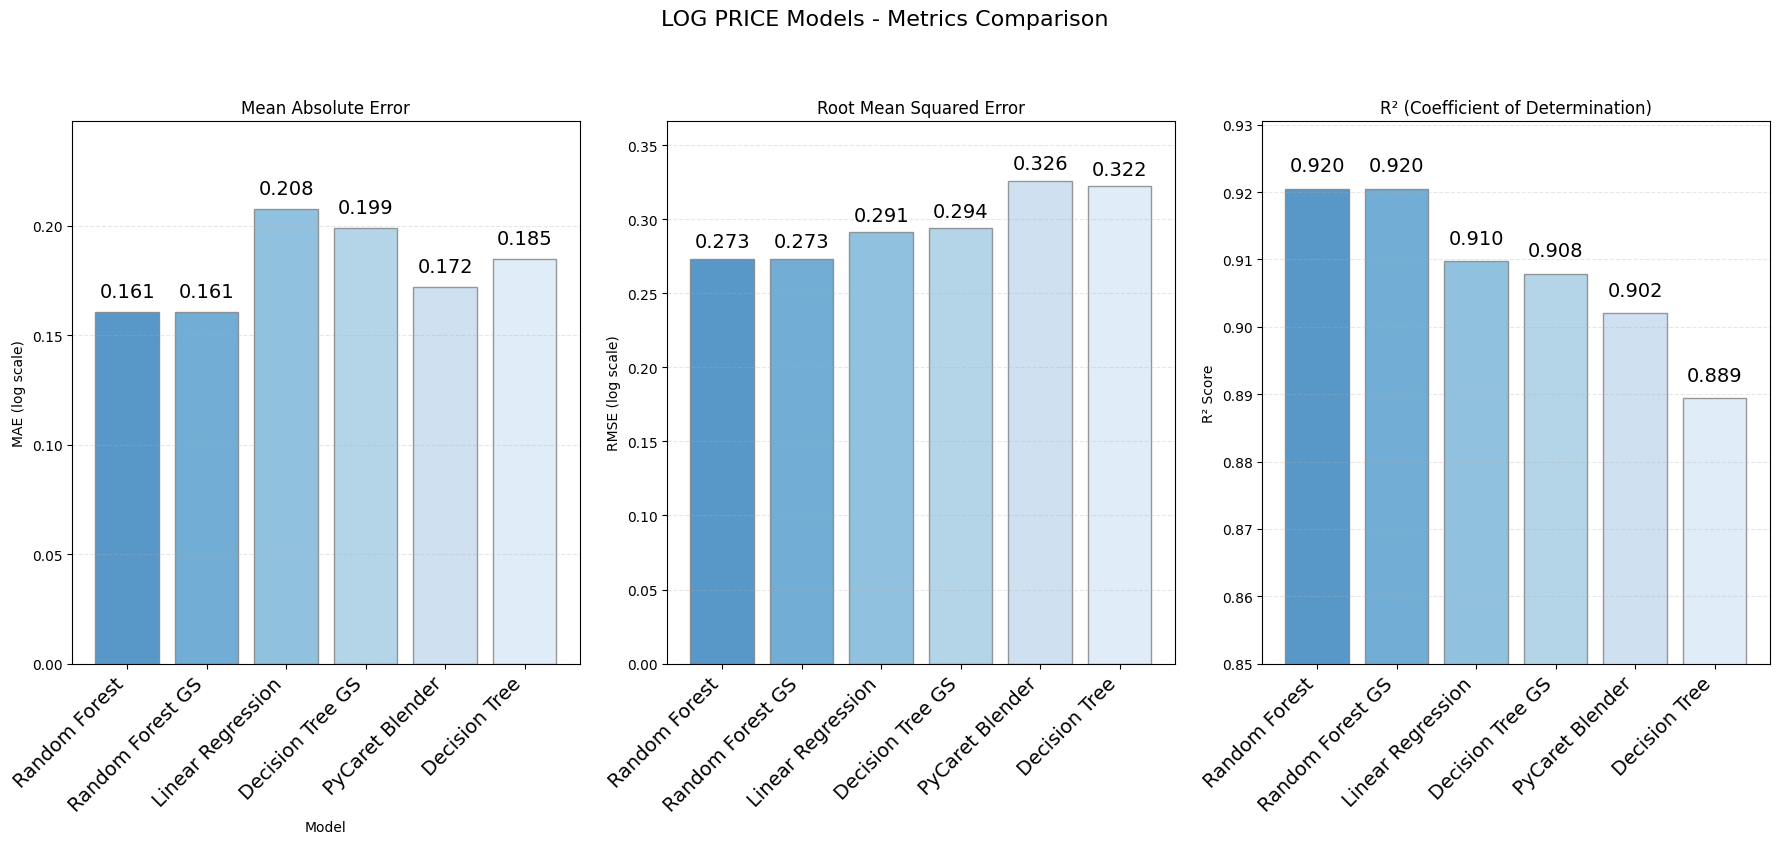

In [0]:
# Filter LOG models
df_log = df_comparison[df_comparison['Target'] == 'log_price'].copy()
df_log = df_log.sort_values('R²', ascending=False)  # Sort by R² descending

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('LOG PRICE Models - Metrics Comparison', fontsize=16, y=1.05)

padding = 0.04
# Use Blues_r palette
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(df_log)))

# Plot 1: MAE (lower is better)
ax1 = axes[0]
ax1.bar(range(len(df_log)), df_log['MAE'], color=colors, alpha=0.8, edgecolor='gray')
ax1.set_xlabel('Model')
ax1.set_ylabel('MAE (log scale)')
ax1.set_title('Mean Absolute Error')
ax1.set_xticks(range(len(df_log)))
ax1.set_xticklabels(df_log['Model'], rotation=45, ha='right', fontsize=14)  
ax1.grid(axis='y', alpha=0.3, linestyle='--')

ax1.set_ylim(0, df_log['MAE'].max() + padding)

# Add value labels on bars (larger font, no bold)
for i, (idx, row) in enumerate(df_log.iterrows()):
    ax1.text(i, row['MAE'] + 0.005, f"{row['MAE']:.3f}", 
             ha='center', va='bottom', fontsize=14)

# Plot 2: RMSE (lower is better)
ax2 = axes[1]
ax2.bar(range(len(df_log)), df_log['RMSE'], color=colors, alpha=0.8, edgecolor='gray')

ax2.set_ylabel('RMSE (log scale)')
ax2.set_title('Root Mean Squared Error') 
ax2.set_xticks(range(len(df_log)))
ax2.set_xticklabels(df_log['Model'], rotation=45, ha='right', fontsize=14)  
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, df_log['RMSE'].max() + padding)

# Add value labels on bars (larger font, no bold)
for i, (idx, row) in enumerate(df_log.iterrows()):
    ax2.text(i, row['RMSE'] + 0.005, f"{row['RMSE']:.3f}", 
             ha='center', va='bottom', fontsize=14)

# Plot 3: R² (higher is better)
ax3 = axes[2]
ax3.bar(range(len(df_log)), df_log['R²'], color=colors, alpha=0.8, edgecolor='gray')
ax3.set_ylabel('R² Score')
ax3.set_title('R² (Coefficient of Determination)', fontsize=12)
ax3.set_xticks(range(len(df_log)))
ax3.set_xticklabels(df_log['Model'], rotation=45, ha='right', fontsize=14) 
ax3.set_ylim(0.85, df_log['R²'].max() + 0.01)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars (larger font, no bold)
for i, (idx, row) in enumerate(df_log.iterrows()):
    ax3.text(i, row['R²'] + 0.002, f"{row['R²']:.3f}", 
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

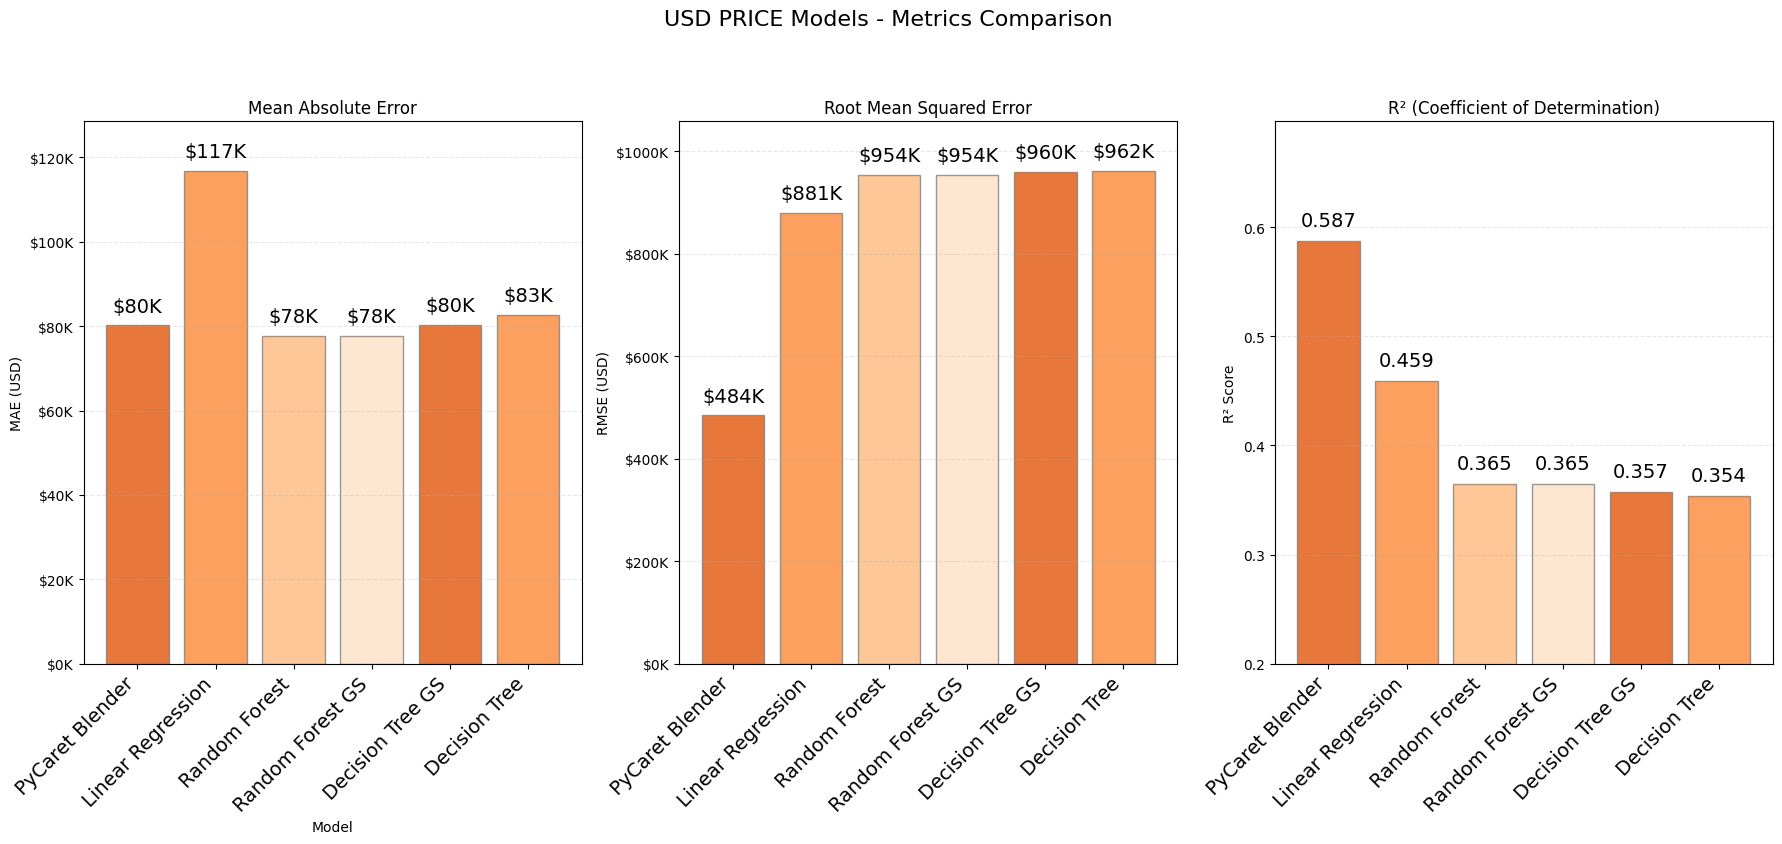

Gray border = Best performing model for that metric


In [0]:
# Use matplotlib's Oranges_r palette if available
# Get Oranges_r palette
colors = plt.cm.Oranges_r(np.linspace(0.3, 0.85, 4))

# Filter USD models
df_usd = df_comparison[df_comparison['Target'] == 'price_usd'].copy()
df_usd = df_usd.sort_values('R²', ascending=False)  # Sort by R² descending

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('USD PRICE Models - Metrics Comparison', fontsize=16, y=1.05)

padding = 0.1

# Plot 1: MAE (lower is better)
ax1 = axes[0]
ax1.bar(range(len(df_usd)), df_usd['MAE'], color=colors, alpha=0.8, edgecolor='gray')
ax1.set_xlabel('Model')
ax1.set_ylabel('MAE (USD)')
ax1.set_title('Mean Absolute Error')
ax1.set_xticks(range(len(df_usd)))
ax1.set_xticklabels(df_usd['Model'], rotation=45, ha='right', fontsize=14)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Format y-axis as currency
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

ax1.set_ylim(0, df_usd['MAE'].max() + padding * df_usd['MAE'].max())

# Add value labels on bars
for i, (idx, row) in enumerate(df_usd.iterrows()):
    ax1.text(i, row['MAE'] + 0.02 * df_usd['MAE'].max(), f"${row['MAE']/1000:.0f}K", 
             ha='center', va='bottom', fontsize=14)

# Plot 2: RMSE (lower is better)
ax2 = axes[1]
ax2.bar(range(len(df_usd)), df_usd['RMSE'], color=colors, alpha=0.8, edgecolor='gray')
ax2.set_ylabel('RMSE (USD)')
ax2.set_title('Root Mean Squared Error')
ax2.set_xticks(range(len(df_usd)))
ax2.set_xticklabels(df_usd['Model'], rotation=45, ha='right', fontsize=14)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Format y-axis as currency
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

ax2.set_ylim(0, df_usd['RMSE'].max() + padding * df_usd['RMSE'].max())

# Add value labels on bars
for i, (idx, row) in enumerate(df_usd.iterrows()):
    ax2.text(i, row['RMSE'] + 0.02 * df_usd['RMSE'].max(), f"${row['RMSE']/1000:.0f}K", 
             ha='center', va='bottom', fontsize=14)

# Plot 3: R² (higher is better)
ax3 = axes[2]
ax3.bar(range(len(df_usd)), df_usd['R²'], color=colors, alpha=0.8, edgecolor='gray')
ax3.set_ylabel('R² Score')
ax3.set_title('R² (Coefficient of Determination)', fontsize=12)
ax3.set_xticks(range(len(df_usd)))
ax3.set_xticklabels(df_usd['Model'], rotation=45, ha='right', fontsize=14)
ax3.set_ylim(0.20, df_usd['R²'].max() + 0.01 + padding)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, row) in enumerate(df_usd.iterrows()):
    ax3.text(i, row['R²'] + 0.01, f"{row['R²']:.3f}", 
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

print("Gray border = Best performing model for that metric")

   
## 8.1 Summary and Key Insights

### Best Models Overall

**LOG Price Prediction (R² = 0.920)**:
* **Random Forest** and **Random Forest GS** (Notebook 06_2) - **TIED**
  * MAE: 0.161 (best)
  * RMSE: 0.273 (best)
  * R²: 0.920 (best)
  * **Identical performance** - GridSearch did not improve over base Random Forest
  * **Winner across all metrics**

**USD Price Prediction (R² = 0.587)**:
* **PyCaret Blender** (Notebook 07) - **BEST R² & RMSE**
  * MAE: $80,179
  * RMSE: $484,416 (best - 45% better than Linear Regression)
  * R²: 0.587 (best - explains 58.7% of variance)
  * **Winner for R² and RMSE**
* **Random Forest / Random Forest GS** (Notebook 06_2) - **BEST MAE**
  * MAE: $77,731 (best - lowest absolute error)
  * RMSE: $954,206
  * R²: 0.365
  * **Winner for MAE**

---

### Complete Rankings

**LOG Scale Models (by R²)**:
1. **Random Forest / Random Forest GS**: R² 0.920, MAE 0.161, RMSE 0.273 BEST
2. **Linear Regression**: R² 0.910, MAE 0.208, RMSE 0.291
3. **Decision Tree GS**: R² 0.908, MAE 0.199, RMSE 0.294
4. **PyCaret Blender**: R² 0.902, MAE 0.172, RMSE 0.326
5. **Decision Tree**: R² 0.889, MAE 0.185, RMSE 0.322

**USD Scale Models (by R²)**:
1. **PyCaret Blender**: R² 0.587, MAE $80,179, RMSE $484,416 BEST R²
2. **Linear Regression**: R² 0.459, MAE $116,867, RMSE $880,558
3. **Random Forest / Random Forest GS**: R² 0.365, MAE $77,731 BEST MAE, RMSE $954,206
4. **Decision Tree GS**: R² 0.357, MAE $80,337, RMSE $959,844
5. **Decision Tree**: R² 0.354, MAE $82,567, RMSE $962,355

---

### Model Performance Analysis

**Random Forest (LOG Scale)**:
* **Dominant performance** on log-transformed prices
* R² = 0.920 means 92% of log-price variance explained
* GridSearch found **no improvement** over base hyperparameters
* Best choice for **proportional accuracy** (MAE 0.161 log units = 17% error)

**PyCaret Blender (LOG Scale)**:
* **Strong ensemble** at R² = 0.902 (90.2% variance explained)
* Competitive MAE (0.172), only 7% worse than Random Forest
* Higher RMSE (0.326) shows **more sensitivity to outliers**
* Fully automated model selection and blending

**PyCaret Blender (USD Scale)** - **BREAKTHROUGH**:
* **Best R² on raw USD** at 0.587 (58.7% variance explained)
* **Best RMSE** at $484K (45% better than Linear Regression's $881K)
* MAE $80K is competitive (only 3% worse than Random Forest's $78K)
* **Why it works**:
  * Ensemble blending reduces outlier sensitivity
  * Combines multiple algorithms (likely LightGBM, CatBoost, XGBoost, Ridge)
  * Handles heterogeneous price ranges ($5K-$18M) better than single models
* **First model to achieve R² > 0.5 on raw USD scale**

**Random Forest (USD Scale)**:
* **Best MAE** at $77,731 (lowest average error per car)
* But R² = 0.365 shows it explains only 36.5% of variance
* High RMSE ($954K) indicates **poor handling of outliers**
* Trade-off: Good average accuracy, poor on expensive cars

**Linear Regression (USD Scale)**:
* **Second best R²** at 0.459 (45.9% variance explained)
* But worst MAE ($117K) and poor RMSE ($881K)
* Struggles with non-linear price relationships

---

### Key Takeaways

1. **LOG transformation remains optimal for maximum accuracy**:
   * LOG models: R² = 0.889-0.920 (excellent)
   * USD models: R² = 0.354-0.587 (fair to good)
   * **51% performance gap** between best LOG (0.920) and best USD (0.587)

2. **GridSearch had minimal impact**:
   * Random Forest GS = Random Forest (identical metrics)
   * Decision Tree GS improved slightly over base (R² 0.908 vs 0.889)
   * **Conclusion**: Base hyperparameters were already near-optimal

3. **Ensemble methods dominate USD scale**:
   * PyCaret Blender wins on R² and RMSE
   * Single Random Forest wins only on MAE
   * **Recommendation**: Use ensembles for raw USD prediction

4. **Metric trade-offs on USD scale**:
   * **Best MAE does not equal Best R²**
   * Random Forest: Low average error ($78K) but only 36.5% variance explained
   * PyCaret: Higher average error ($80K) but 58.7% variance explained
   * **Choice depends on use case**:
     * Minimize average error → Random Forest
     * Maximize predictive power → PyCaret Blender

5. **Production deployment recommendations**:
   * **Option 1 (Best overall accuracy)**: Random Forest on LOG scale
     * Predict `log_price`, then transform: `price_usd = np.expm1(log_price_pred)`
     * R² = 0.920, MAE = 0.161 log units (~17% proportional error)
     * **Best for**: Applications requiring highest accuracy
   
   * **Option 2 (Direct USD, best variance)**: PyCaret Blender on USD scale
     * Direct USD predictions without transformation
     * R² = 0.587, RMSE = $484K
     * **Best for**: Applications requiring interpretable dollar predictions
   
   * **Option 3 (Direct USD, best average)**: Random Forest on USD scale
     * Direct USD predictions
     * MAE = $78K (best average error)
     * **Best for**: Applications prioritizing average accuracy over variance explained

---

### Saved Model Files

All trained models are saved as `.pkl` files in the **Models/** folder:

**Notebooks 06_1 and 06_2**:
* `model_lr_log.pkl`, `model_lr_usd.pkl` - Linear Regression
* `model_dt_log.pkl`, `model_dt_usd.pkl` - Decision Tree (base)
* `model_rf_log.pkl`, `model_rf_usd.pkl` - Random Forest (base)
* `model_dt_log_best.pkl`, `model_dt_usd_best.pkl` - Decision Tree (GridSearch)
* `model_rf_log_best.pkl`, `model_rf_usd_best.pkl` - Random Forest (GridSearch)

**Notebook 07 (PyCaret)**:
* `pycaret_blender_log.pkl` - **Blended ensemble for LOG price** (R² 0.902)
* `pycaret_blender_usd.pkl` - **Blended ensemble for USD price** (R² 0.587, best USD)
* `pycaret_best_log.pkl` - Single LGBMRegressor for LOG
* `pycaret_best_usd.pkl` - Single HuberRegressor for USD
* `X_test_pycaret_log.pkl`, `y_test_pycaret_log.pkl` - PyCaret LOG test data
* `X_test_pycaret_usd.pkl`, `y_test_pycaret_usd.pkl` - PyCaret USD test data

**Models are ready for**:
* Deployment via `joblib.load()`
* Inference on new car data
* API endpoints for real-time predictions
* Further ensemble stacking or hyperparameter tuning